In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path('/Volumes/Lenovo PS10/Qwen2.5-3B-Instruct')
CATEGORY_FILTER = None  # e.g. {'linguistic_style', 'ideology'}
PAIR_FILTER = None  # e.g. {'linguistic_style__concise__verbose'}

assert ROOT.exists(), f'Not found: {ROOT}'
ROOT


PosixPath('/Volumes/Lenovo PS10/Qwen2.5-3B-Instruct')

In [2]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return float(np.dot(a, b) / denom)


def parse_pair_dir(pair_dir: Path) -> dict:
    metadata_path = pair_dir / 'metadata.json'
    metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    examples = metadata.get('examples', [])
    first_example = examples[0] if examples else {}

    return {
        'pair_dir': pair_dir,
        'category_key': first_example.get('category_key', pair_dir.parent.name),
        'category_name': first_example.get('category_name', pair_dir.parent.name),
        'pair_slug': first_example.get('pair_slug', pair_dir.name),
        'positive_concept': first_example.get('positive_concept', ''),
        'negative_concept': first_example.get('negative_concept', ''),
        'layers': metadata['run_config']['hidden_layers'],
        'variant_counts': metadata.get('variant_counts', {}),
    }


def iter_pair_infos(root: Path):
    for category_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        if CATEGORY_FILTER and category_dir.name not in CATEGORY_FILTER:
            continue
        for pair_dir in sorted(path for path in category_dir.iterdir() if path.is_dir()):
            if PAIR_FILTER and pair_dir.name not in PAIR_FILTER:
                continue
            metadata_path = pair_dir / 'metadata.json'
            if metadata_path.exists():
                yield parse_pair_dir(pair_dir)


def load_layer_matrix(pair_dir: Path, variant: str, layer: int) -> np.ndarray:
    layer_path = pair_dir / variant / f'layer_{layer}.npy'
    return np.load(layer_path)


def build_steering_results(root: Path):
    rows = []
    steering_vectors = {}

    for pair_info in iter_pair_infos(root):
        pair_dir = pair_info['pair_dir']
        pair_slug = pair_info['pair_slug']
        steering_vectors[pair_slug] = {}

        for layer in sorted(pair_info['layers']):
            positive = load_layer_matrix(pair_dir, 'positive', layer)
            base = load_layer_matrix(pair_dir, 'base', layer)
            negative = load_layer_matrix(pair_dir, 'negative', layer)

            pos_minus_base = positive.mean(axis=0) - base.mean(axis=0)
            neg_minus_base = negative.mean(axis=0) - base.mean(axis=0)
            cos_sim = cosine_similarity(pos_minus_base, neg_minus_base)

            steering_vectors[pair_slug][layer] = {
                'pos_minus_base': pos_minus_base,
                'neg_minus_base': neg_minus_base,
            }

            rows.append({
                'category_key': pair_info['category_key'],
                'category_name': pair_info['category_name'],
                'pair_slug': pair_slug,
                'concept_label': f"{pair_info['positive_concept']} vs {pair_info['negative_concept']}",
                'positive_concept': pair_info['positive_concept'],
                'negative_concept': pair_info['negative_concept'],
                'layer': layer,
                'layer_depth': -layer,
                'n_positive': positive.shape[0],
                'n_base': base.shape[0],
                'n_negative': negative.shape[0],
                'hidden_dim': positive.shape[1],
                'pos_base_norm': float(np.linalg.norm(pos_minus_base)),
                'neg_base_norm': float(np.linalg.norm(neg_minus_base)),
                'cos_similarity': cos_sim,
            })

    results_df = pd.DataFrame(rows).sort_values(['category_key', 'pair_slug', 'layer'])
    return results_df.reset_index(drop=True), steering_vectors


def plot_pair_cosine(results_df: pd.DataFrame, pair_slug: str, ax=None):
    pair_df = results_df.loc[results_df['pair_slug'] == pair_slug].sort_values('layer')
    if pair_df.empty:
        raise ValueError(f'Unknown pair_slug: {pair_slug}')

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    ax.plot(pair_df['layer_depth'], pair_df['cos_similarity'], marker='o', linewidth=1.5)
    ax.axhline(0.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xlabel('Layer depth (1 = last layer, larger = earlier layer)')
    ax.set_ylabel('cos(pos-base, neg-base)')
    ax.set_title(pair_df['concept_label'].iloc[0])
    ax.grid(alpha=0.25)
    return ax


def make_cosine_heatmap(results_df: pd.DataFrame, category_key: str | None = None, figsize=(12, 18)):
    subset = results_df.copy()
    if category_key is not None:
        subset = subset.loc[subset['category_key'] == category_key]

    heatmap_df = subset.pivot(index='concept_label', columns='layer_depth', values='cos_similarity')
    heatmap_df = heatmap_df.reindex(sorted(heatmap_df.columns), axis=1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_df.to_numpy(), aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(range(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)
    ax.set_xlabel('Layer depth (1 = last layer)')
    ax.set_ylabel('Concept pair')
    ax.set_title('cos(pos-base, neg-base)' if category_key is None else f'{category_key}: cos(pos-base, neg-base)')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    return heatmap_df


In [3]:
results_df, steering_vectors = build_steering_results(ROOT)

print(f'Loaded {results_df["pair_slug"].nunique()} pairs across {results_df["category_key"].nunique()} categories')
print(f'Layers per pair: {results_df["layer"].nunique()}')
display(results_df.head())


Loaded 150 pairs across 3 categories
Layers per pair: 35


,category_key,category_name,pair_slug,concept_label,positive_concept,negative_concept,layer,layer_depth,n_positive,n_base,n_negative,hidden_dim,pos_base_norm,neg_base_norm,cos_similarity
0,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,-35,35,100,100,100,2048,1.478382,0.972564,0.863686
1,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,-34,34,100,100,100,2048,1.693023,1.195396,0.869195
2,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,-33,33,100,100,100,2048,2.222989,1.710042,0.909567
3,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,-32,32,100,100,100,2048,3.019221,2.630084,0.934312
4,ideology,IDEOLOGY,ideology__centralization_support__decentraliza...,centralization-support vs decentralization-sup...,centralization-support,decentralization-support,-31,31,100,100,100,2048,3.346270,2.885521,0.928042


In [4]:
layer_summary = (
    results_df.groupby('layer_depth', as_index=False)
    .agg(
        mean_cos_similarity=('cos_similarity', 'mean'),
        median_cos_similarity=('cos_similarity', 'median'),
        mean_pos_base_norm=('pos_base_norm', 'mean'),
        mean_neg_base_norm=('neg_base_norm', 'mean'),
        num_pairs=('pair_slug', 'nunique'),
    )
    .sort_values('layer_depth')
)

display(layer_summary)

top_parallel = results_df.sort_values('cos_similarity', ascending=False)[
    ['category_key', 'concept_label', 'layer_depth', 'cos_similarity', 'pos_base_norm', 'neg_base_norm']
].head(20)

top_opposite = results_df.sort_values('cos_similarity', ascending=True)[
    ['category_key', 'concept_label', 'layer_depth', 'cos_similarity', 'pos_base_norm', 'neg_base_norm']
].head(20)

display(top_parallel)
display(top_opposite)


,layer_depth,mean_cos_similarity,median_cos_similarity,mean_pos_base_norm,mean_neg_base_norm,num_pairs
0,1,0.919850,0.949229,16.392045,16.678777,150
1,2,0.916314,0.945685,21.976691,22.585225,150
2,3,0.912167,0.940379,17.392898,17.851458,150
3,4,0.903602,0.933620,17.133866,17.420792,150
4,5,0.902836,0.932905,16.006056,16.408086,150
5,6,0.922163,0.948898,13.863523,14.262364,150
6,7,0.927869,0.952960,13.713643,14.180689,150
7,8,0.931453,0.954526,13.229209,13.615495,150
8,9,0.933524,0.958864,13.083201,13.380233,150
9,10,0.936527,0.960184,13.291085,13.704028,150


,category_key,concept_label,layer_depth,cos_similarity,pos_base_norm,neg_base_norm
3906,semantic_framing,efficiency-analysis perspective vs equity-anal...,14,0.992513,11.625739,12.288815
3905,semantic_framing,efficiency-analysis perspective vs equity-anal...,15,0.992197,11.153325,11.842973
3661,semantic_framing,competition perspective vs cooperation perspec...,14,0.992114,11.417192,11.623275
3660,semantic_framing,competition perspective vs cooperation perspec...,15,0.991800,10.927060,11.124771
3664,semantic_framing,competition perspective vs cooperation perspec...,11,0.991342,13.825914,13.840421
3659,semantic_framing,competition perspective vs cooperation perspec...,16,0.990990,10.683321,10.970790
3904,semantic_framing,efficiency-analysis perspective vs equity-anal...,16,0.990871,10.874238,11.639427
3665,semantic_framing,competition perspective vs cooperation perspec...,10,0.990567,14.213315,14.190117
3666,semantic_framing,competition perspective vs cooperation perspec...,9,0.990477,13.859808,13.802188
4816,semantic_framing,problem perspective vs solution perspective,14,0.990429,11.522055,11.812317


,category_key,concept_label,layer_depth,cos_similarity,pos_base_norm,neg_base_norm
2823,linguistic_style,minimal vs extensive,12,0.599482,15.895267,15.220967
2834,linguistic_style,minimal vs extensive,1,0.641396,19.242945,17.508644
2833,linguistic_style,minimal vs extensive,2,0.643730,27.064341,24.218222
2832,linguistic_style,minimal vs extensive,3,0.653613,22.371952,18.768026
2830,linguistic_style,minimal vs extensive,5,0.653869,21.453978,17.239307
3426,linguistic_style,terminology-heavy vs terminology-light,4,0.654030,18.036524,20.290657
2831,linguistic_style,minimal vs extensive,4,0.655109,23.110178,18.312538
280,ideology,economic-growth-priority vs sustainability-pri...,35,0.656096,1.572372,1.011934
2123,linguistic_style,concise vs verbose,12,0.656543,14.314740,14.791253
3425,linguistic_style,terminology-heavy vs terminology-light,5,0.657956,17.012270,19.032406


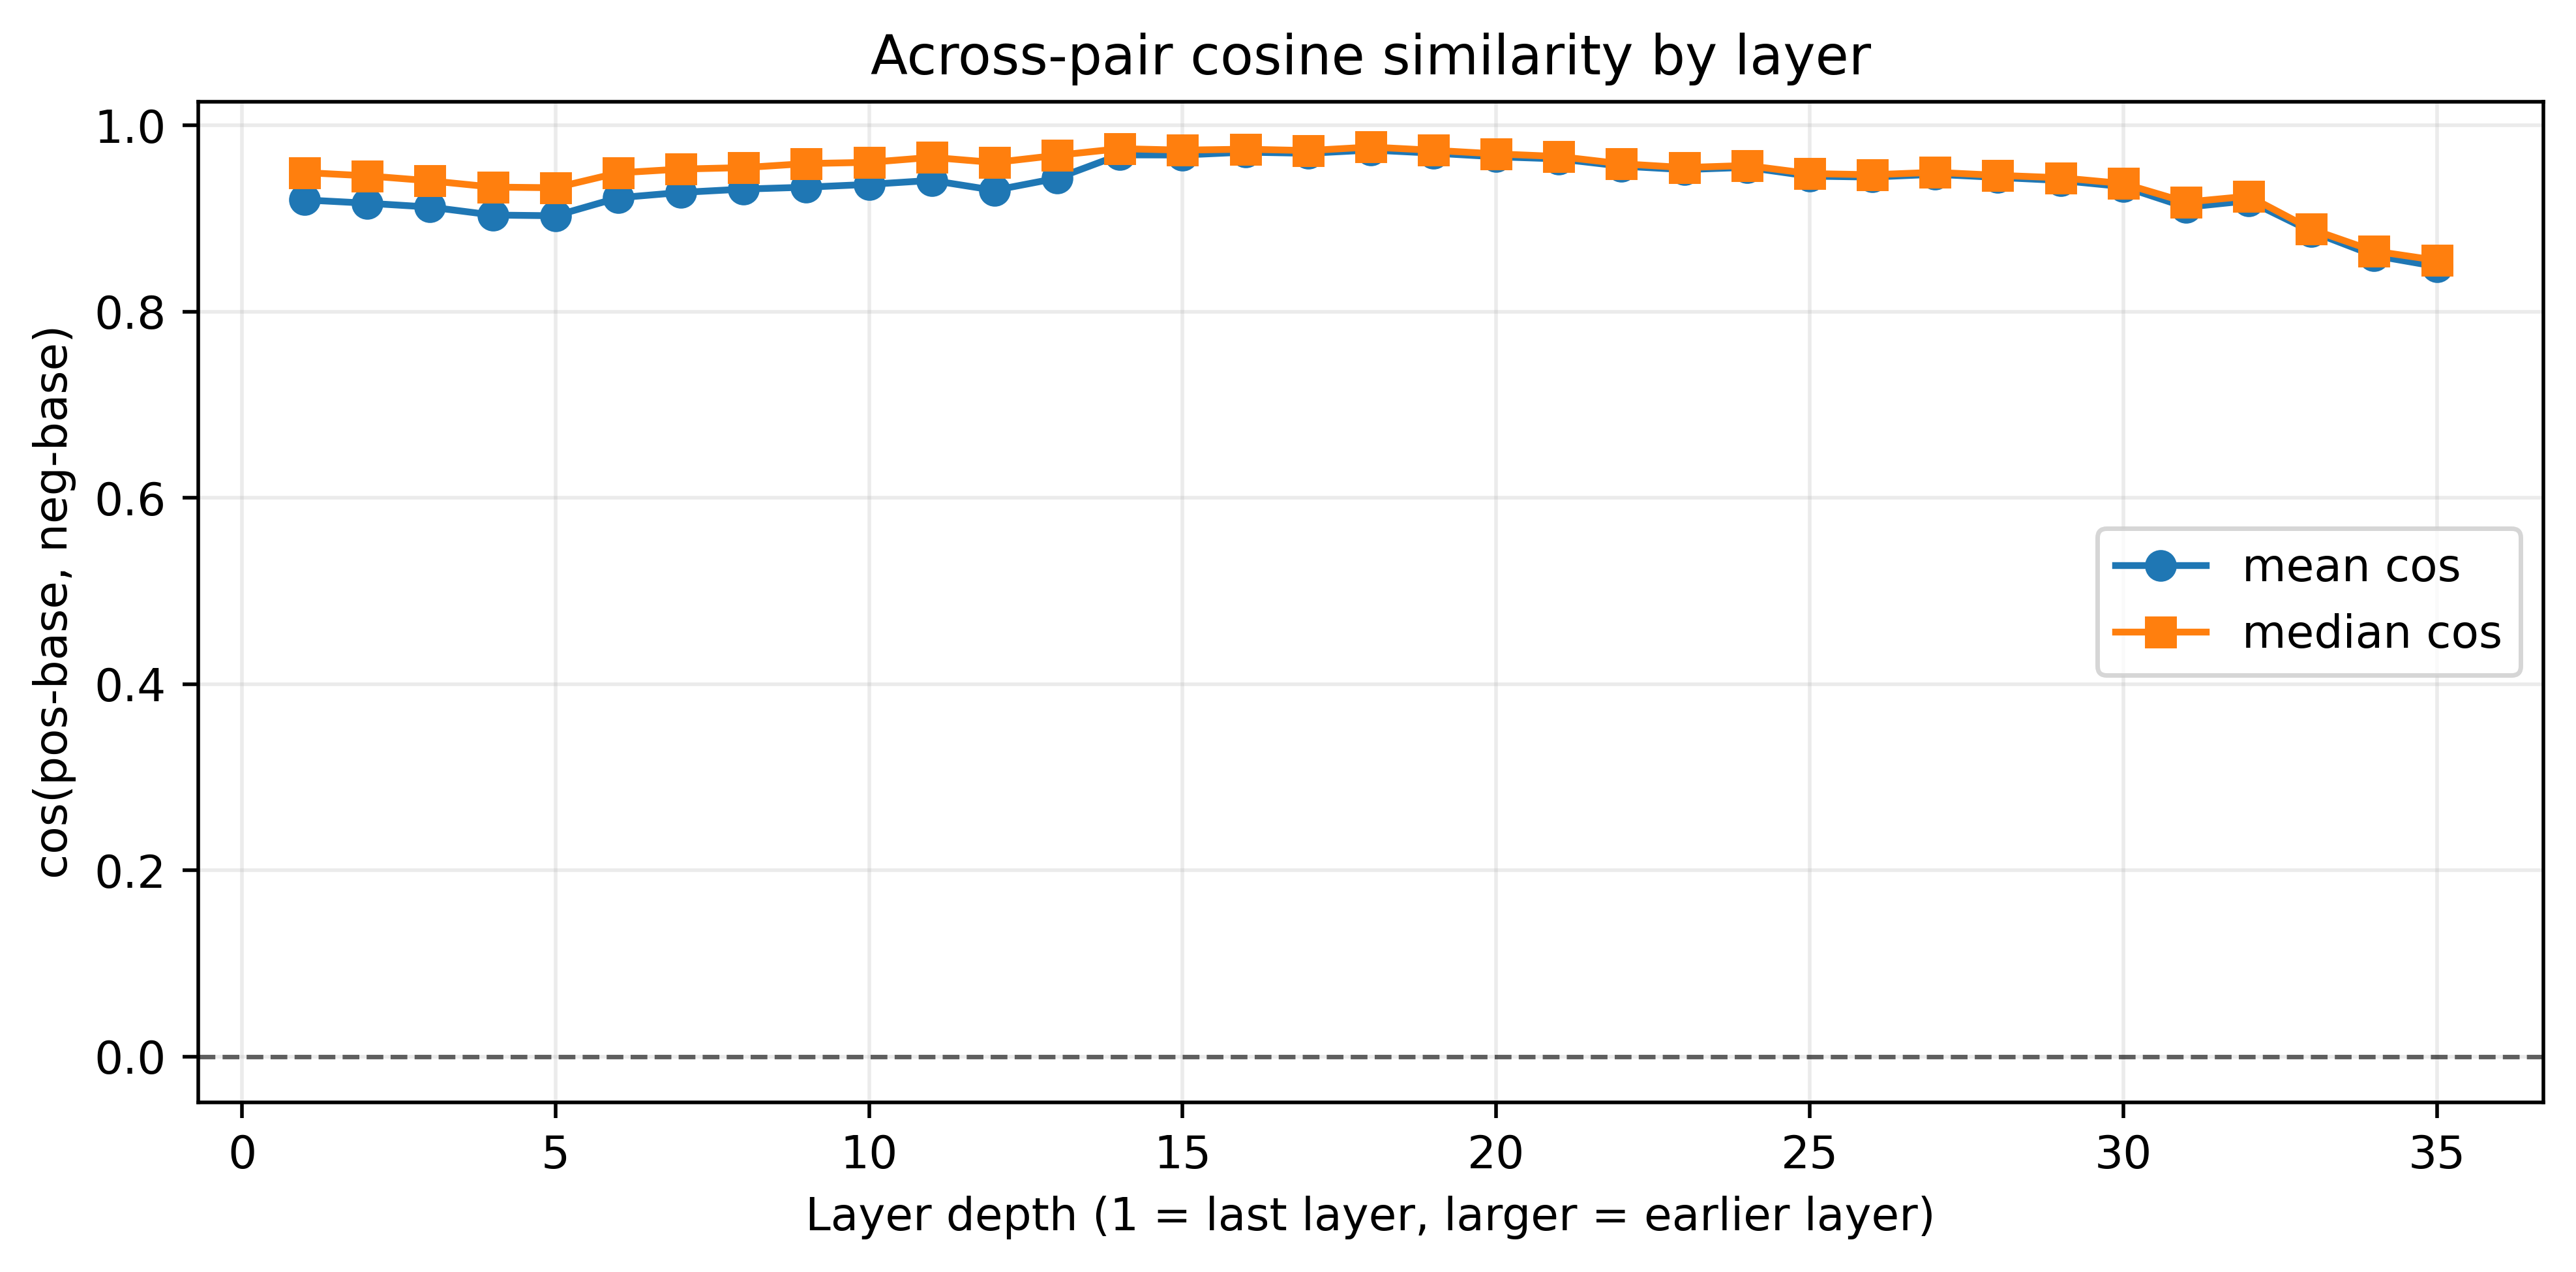

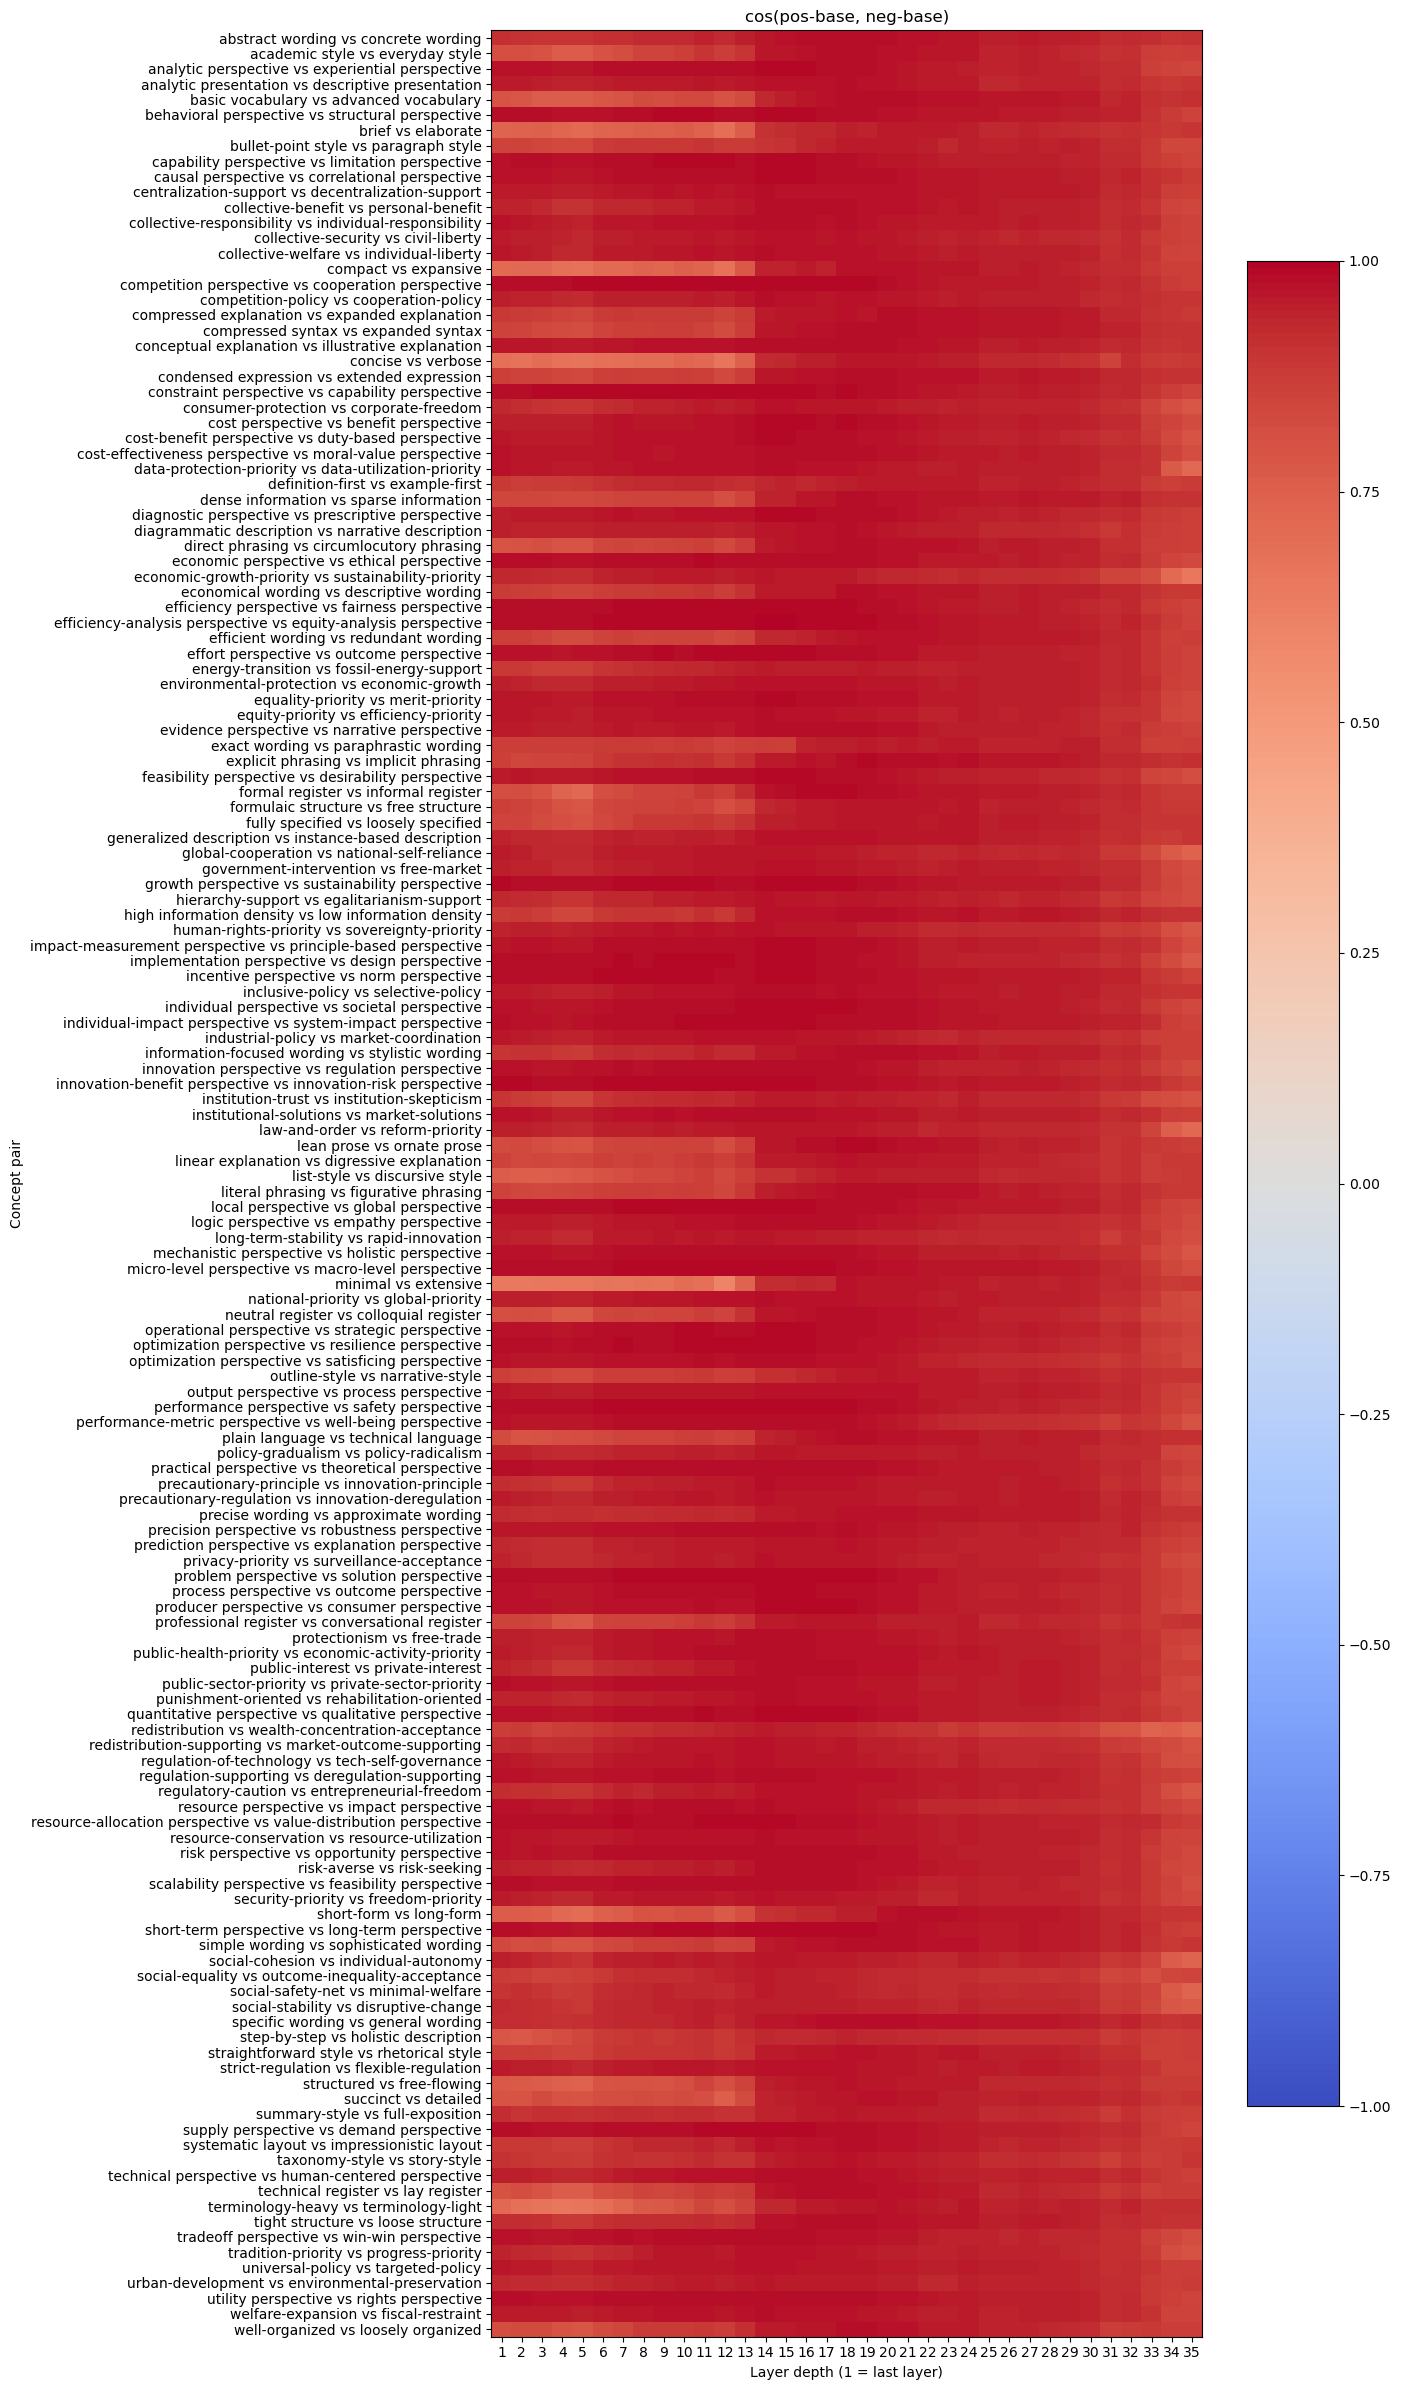

In [7]:
plt.figure(figsize=(8, 4), dpi=500)
plt.plot(layer_summary['layer_depth'], layer_summary['mean_cos_similarity'], marker='o', label='mean cos')
plt.plot(layer_summary['layer_depth'], layer_summary['median_cos_similarity'], marker='s', label='median cos')
plt.axhline(0.0, color='black', linewidth=1, linestyle='--', alpha=0.6)
plt.xlabel('Layer depth (1 = last layer, larger = earlier layer)')
plt.ylabel('cos(pos-base, neg-base)')
plt.title('Across-pair cosine similarity by layer')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

make_cosine_heatmap(results_df, figsize=(14, 24));


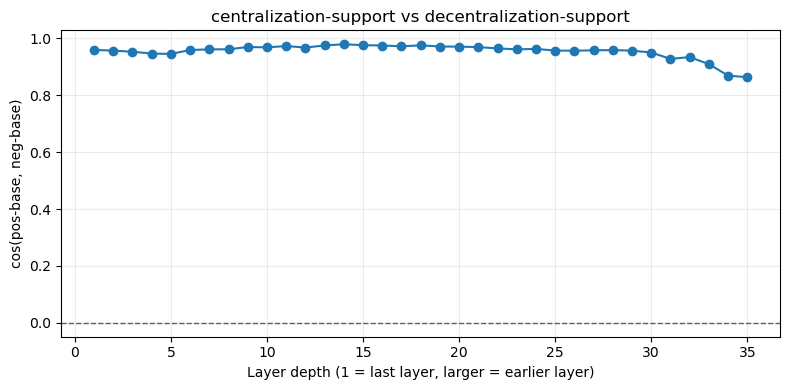

,category_key,concept_label,layer_depth,cos_similarity,pos_base_norm,neg_base_norm
34,ideology,centralization-support vs decentralization-sup...,1,0.959541,13.853554,13.393447
33,ideology,centralization-support vs decentralization-sup...,2,0.957135,18.501776,17.711681
32,ideology,centralization-support vs decentralization-sup...,3,0.953215,14.127063,13.518545
31,ideology,centralization-support vs decentralization-sup...,4,0.946778,13.724415,13.070423
30,ideology,centralization-support vs decentralization-sup...,5,0.945510,12.807469,12.295009
29,ideology,centralization-support vs decentralization-sup...,6,0.959219,11.137469,10.764814
28,ideology,centralization-support vs decentralization-sup...,7,0.961478,10.851984,10.694100
27,ideology,centralization-support vs decentralization-sup...,8,0.961826,10.532922,10.364532
26,ideology,centralization-support vs decentralization-sup...,9,0.969806,10.357004,10.190120
25,ideology,centralization-support vs decentralization-sup...,10,0.968545,10.387149,10.276314


In [8]:
pair_slug = results_df['pair_slug'].iloc[0]
pair_slug

plot_pair_cosine(results_df, pair_slug)
plt.tight_layout()
plt.show()

display(
    results_df.loc[results_df['pair_slug'] == pair_slug, [
        'category_key',
        'concept_label',
        'layer_depth',
        'cos_similarity',
        'pos_base_norm',
        'neg_base_norm',
    ]].sort_values('layer_depth')
)
